# First model: Basic Gaussian Mixture

While the end-goal of this project is to have a functioning Hidden Markov Model to capture the temporal behaviour of our crops, it is first necessary for us to establish a baseline model operating under the assumption of statistical independence. The inherent problem of this project is unsupervised, therefore we consider a range of unsupervised models, starting off with clustering. The approach of fitting a GMM in this notebook answers the question: **Are conditions behaving abnormally right now?**

In [35]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture 
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from models import NDVIClimatologyGAM, LikelihoodGMM, ForecastingGMM, ForecastingGMMSelector
from data import utils, DatasetBuilder, DatasetLoader, DatasetScalerSplitter

from features import (
    FeaturePipeline, 
    PhenologyFeatures, 
    RollingFeatures, 
    SoilFeatures, 
    TemporalFeatures
)

## Load Data

In [37]:
loader = DatasetLoader(raw_data_dir="../data/raw/", engineered_data_dir="../data/processed/")
non_spectral_df = loader.non_spectral()
grouped_spectral_df = loader.grouped_spectral()
master_df = utils.merge_with_master(grouped_spectral_df, non_spectral_df)


In [38]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])
eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')


In [39]:
# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

### Engineered features

In [40]:
gam = NDVIClimatologyGAM(n_splines=30)

X = master_df["Timestamp"].dt.dayofyear.values.reshape(-1, 1)
y = master_df["NDVI_mean"].values

gam.gridsearch(doys=X, ndvi=y)

sos = gam.start_of_season(position="late")
eos = gam.end_of_season()
eos

100% (25 of 25) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


np.int64(174)

In [41]:
pipe = FeaturePipeline(
    PhenologyFeatures(start_of_season=sos, end_of_season=eos),
    SoilFeatures(moisture_pca=True, root_weighted_moisture=True, temperature_pca=True),
    TemporalFeatures(start_of_season=sos, cyclic_doy=True)
)

pipe.fit(non_spectral_df)
non_spectral_df = pipe.transform(non_spectral_df)
non_spectral_df.columns

1
238


Index(['Timestamp', 'volumetric_soil_water_layer_1',
       'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3',
       'volumetric_soil_water_layer_4', 'soil_temperature_level_1',
       'soil_temperature_level_2', 'soil_temperature_level_3',
       'soil_temperature_level_4', 'temperature_2m', 'temperature_2m_min',
       'temperature_2m_max', 'surface_solar_radiation_downwards_sum',
       'precipitation', 'Ag_year', 'in_season', 'GDD', 'cumulative_GDD',
       'Growth_Stage', 'root_weighted_soil_moisture', 'VW_PC1', 'ST_PC1',
       'doy_sin', 'doy_cos'],
      dtype='object')

### Interpolation

We present the first issue of our data using a simple merge between the non-spectral and spectral datasets.

In [42]:
master_raw_df = grouped_spectral_df.merge(non_spectral_df, on="Timestamp" ,how='right')
master_raw_df.head(7)

,Timestamp,NDVI_mean,NDVI_std,NDWI_mean,NDWI_std,NDRE_mean,NDRE_std,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,...,Ag_year,in_season,GDD,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1,ST_PC1,doy_sin,doy_cos
0,2018-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.371225,0.394800,0.302474,...,2017,1,10.006207,10.006207,SoS,0.377979,0.918978,1.550109,0.899296,0.437340
1,2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.347555,0.379907,0.302010,...,2017,1,7.404952,17.411159,SoS,0.359874,0.533468,1.465590,0.906686,0.421806
2,2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.330737,0.367946,0.301465,...,2017,1,7.165753,24.576912,SoS,0.346349,0.244641,1.450933,0.913808,0.406147
3,2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,0.315402,0.356416,0.300741,...,2017,1,8.108309,32.685221,SoS,0.333711,-0.025467,1.541121,0.920659,0.390368
4,2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,0.302094,0.344448,0.299777,...,2017,1,10.420760,43.105980,SoS,0.321802,-0.281085,1.741368,0.927238,0.374474
5,2018-01-06,NaN,NaN,NaN,NaN,NaN,NaN,0.290550,0.332584,0.298607,...,2017,1,11.965887,55.071867,SoS,0.310757,-0.518841,1.990642,0.933542,0.358468
6,2018-01-07,0.454175,0.017789,0.15485,0.001513,0.301027,0.005391,0.277943,0.320916,0.297231,...,2017,1,13.500111,68.571978,VE,0.299292,-0.764578,2.313807,0.939570,0.342357


You will quickly notice that our spectral indices contain lots of `NaN` observations. This is due to the almost-weekly passes of the Sentinel-2 mission, as well as cloud-masking applied in our pre-processing steps. Luckily, NDVI follows a pretty general pattern and is not prone to extreme oscilations from one moment to the next. It is therefore not a bad idea to use the built-in **Cubic Hermit Spline** wrapper to `scipy` in `pandas` to account for these unobserved images. 

Note we also use **backfilling** to account for the missing observations at the start of our datasets, as the spectral indices are unlikely to vary much in such a short period.

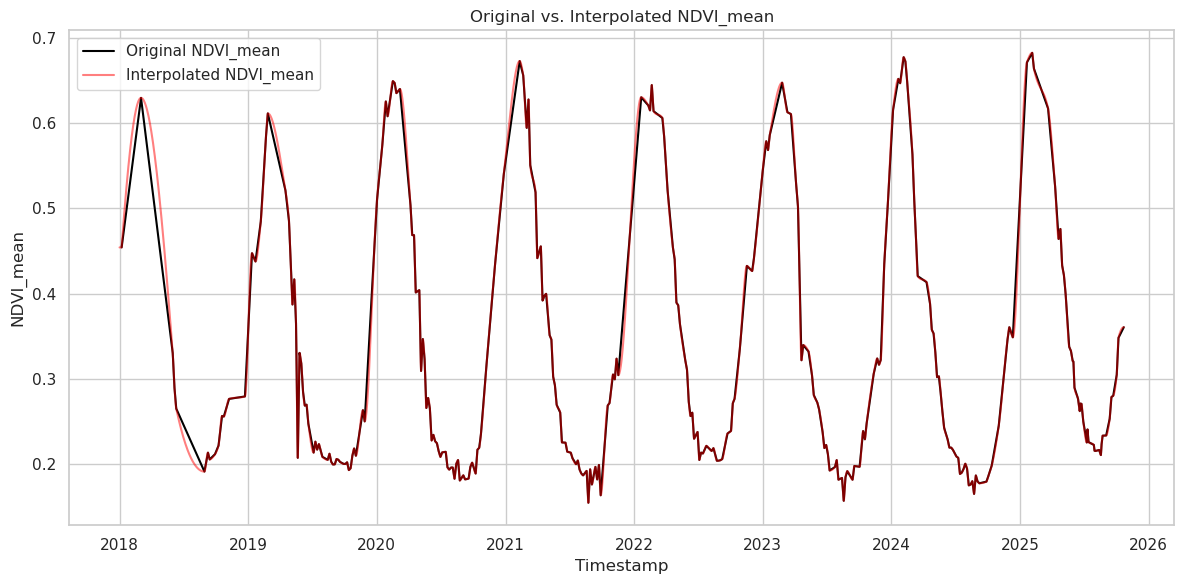

In [43]:
spectral_features = grouped_spectral_df.columns.drop("Timestamp")
builder = DatasetBuilder()

built_df = (
    builder
    .merge_non_spectral(non_spectral=non_spectral_df)
    .merge_spectral(grouped_spectral_df)
    .interpolate(val_columns=spectral_features, dropna=True)
    .build()
)

builder.plot_interpolate(data=grouped_spectral_df, x="Timestamp", y="NDVI_mean")

---

## Full Model, no lagged variables or rolling statistics

As a baseline, we fit a GMM on all our engineered and remaining non-spectral variables. The log likelihood of the training sample will give us a good indication of how well the model fit to the data. Note that, since GMM's assume _continuous_ variables, we do not explicitly make use of the `in_season` or `Growth-Stage` features. We will operate under the assumption that this information is baked into `cummulative_GDD`.

In [54]:
non_spectral_features = [
    'Timestamp',
    'temperature_2m',
    #'temperature_2m_min',
    #'temperature_2m_max', 
    #'surface_solar_radiation_downwards_sum',
    'precipitation',
    'volumetric_soil_water_layer_3',
    #'volumetric_soil_water_layer_4',
    'soil_temperature_level_4'
]

spectral_features = [
    "NDVI_mean",
    "NDWI_mean",
    "NDRE_mean",
]

eng_features = [
    # Timestamp for merging

    # Date features for plotting
    #"shifted_doy",
    "Ag_year",

    # engineered features
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    #'VW_PC1',  
    #'Shallow_mean',
    'ST_PC1',

    # Categoricals not included
    #'Growth_Stage',
    'in_season',

    #temporal
    'doy_sin',
    'doy_cos'
]


builder = builder.select_columns(eng_features + non_spectral_features + spectral_features)

### Extracting Anomaly Data

An immediate answer to the question "Why fit a GMM?" is apparent here. Our anomly years found in the EDA process are _not_ a sequential set (2018-2019, 2023, maybe 2024). This means there will be a time gap between the training years. In a **sequential** model like an HMM, this would be a problem, but a GMM makes the assumption of statistical independence, so the gap doesn't matter. 

In [55]:
norm_df, anom_df = builder.split_by_growing_season(2018, 2019, 2023, 2024)

In [56]:
train_mask = norm_df["Ag_year"] < 2022
test_mask = norm_df["Ag_year"] >= 2022
passthrough_cols = ["doy_sin", "doy_cos"]
drop_cols = ["Timestamp", "shifted_doy", "doy", "GDD", "in_season", "Ag_year"]

scaler_splitter = DatasetScalerSplitter(
    train_mask=train_mask, 
    test_mask=test_mask, 
    passthrough_cols=passthrough_cols,
    drop_cols=drop_cols
)

scaler_splitter.fit(norm_df)

X_train_df, X_test_df = scaler_splitter.train_test_split_transform(norm_df)
X_anom_df = scaler_splitter.transform(anom_df)

In [57]:
gmm = LikelihoodGMM(
    n_components=17, 
    covariance_type='full',
    reg_covar=1e-03,
    n_init=10
)
components = range(1, 20)
gmm.cv_fit(X_train_df, components)

Minimum BIC: -11215.02 with 10 components and 'full' covariance.


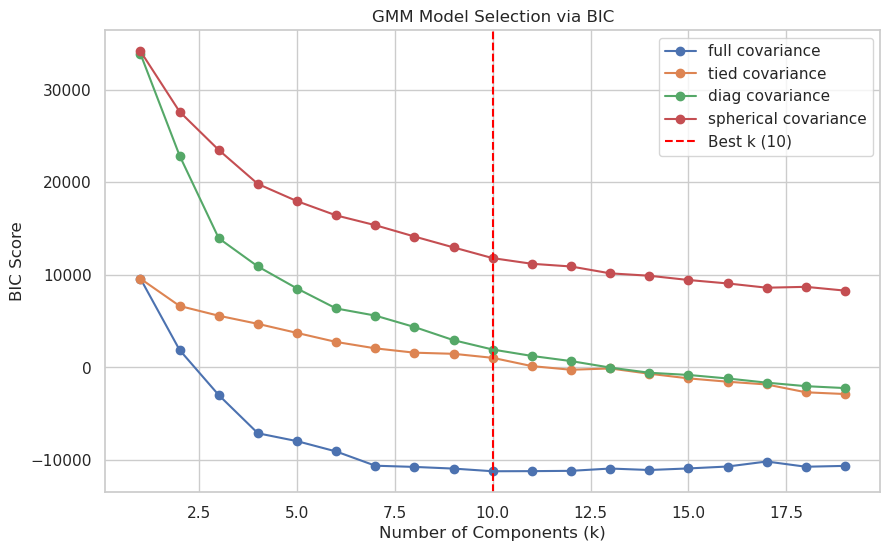

In [58]:
gmm.plot_bic_curve()

In [60]:
elbow_gmm = LikelihoodGMM(
    n_components=7, 
    covariance_type=gmm.covariance_type,
    reg_covar=gmm.reg_covar,
    n_init=gmm.n_init
)
elbow_gmm.fit(X_train_df)

In [61]:
print(f"{'':<35}{'Lowest BIC model':<25}{'Elbow Model'}")
print("-" * 80)
print(f"{'Test data log-likelihood':<35}{gmm.score(X_test_df):.2f}{'':<18}{elbow_gmm.score(X_test_df):.2f}")
print(f"{'Anomaly data log-likelihood':<35}{gmm.score(X_anom_df):.2f}{'':<18}{elbow_gmm.score(X_anom_df):.2f}")

                                   Lowest BIC model         Elbow Model
--------------------------------------------------------------------------------
Test data log-likelihood           -7.12                  -4.02
Anomaly data log-likelihood        -63.53                  -70.86


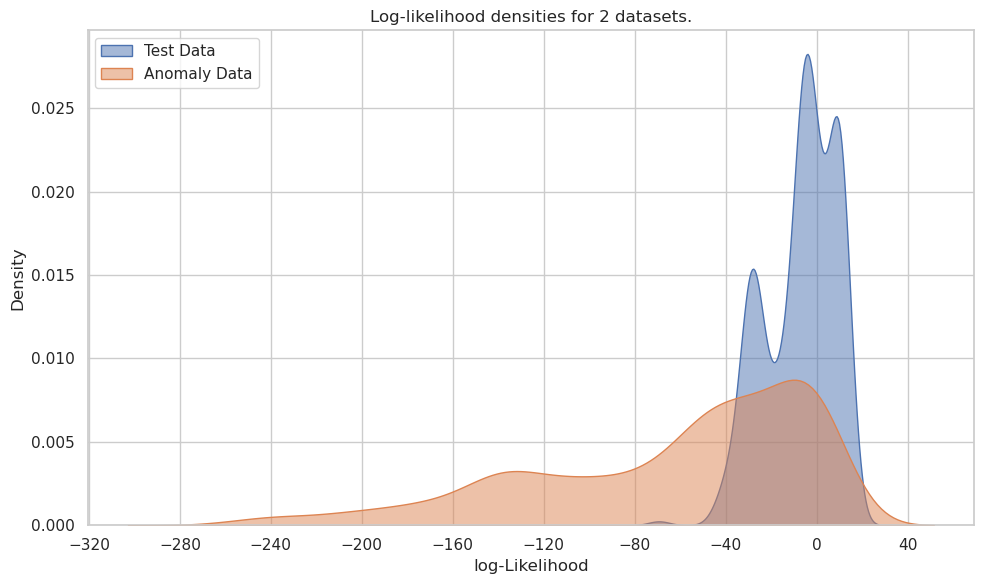

In [67]:
gmm.plot_likelihood_kde(X_test_df, X_anom_df, labels=["Test Data", "Anomaly Data"])

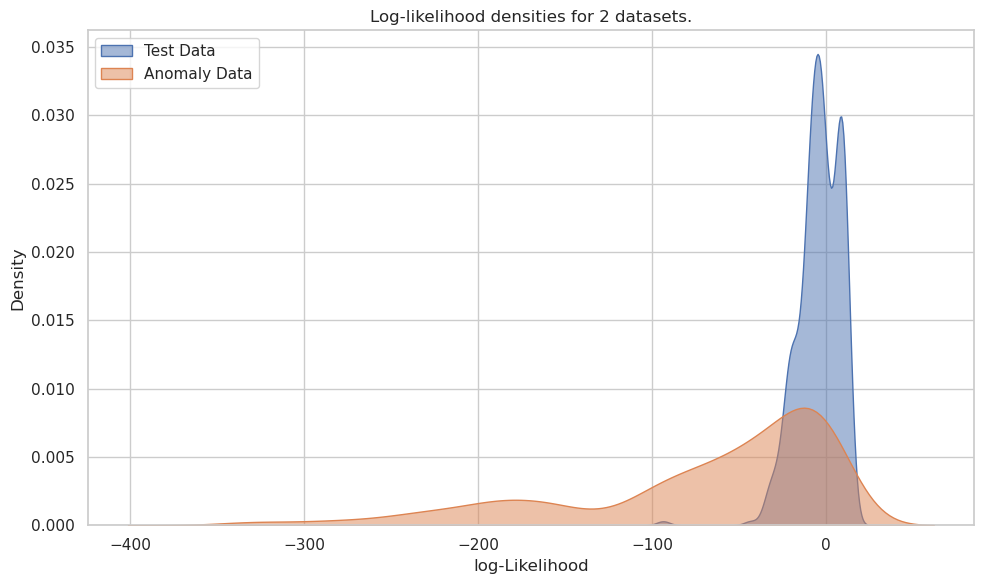

In [63]:
elbow_gmm.plot_likelihood_kde(X_test_df, X_anom_df, labels=["Test Data", "Anomaly Data"])

---

## Rolling and Lagged variables

While our first model does have pretty surprising performance, it does operate under two assumptions violated by the data:
1. **Independence between observations**.
2. **No temporal behaviour of variables**: The baseline GMM does not in any way use _past_ environmental data for _current_ observations during its clustering. This is a bad strategy for time series agricultural data because, for example, rain will not have a meaningful effect on a crop until a few days _after_ it has occurred. Similarly, a single day's drought will not put a plant under stress, but rather an _accumulation_ of days of drought.

While we cannot address the independence assumption since that is a defining characteristic of a GMM, we can include rolled statistics and lagging variables to force the model to learn on temporal data.

In [ ]:
roll_lag_features = [
    "Timestamp",
    
    # Temperature
    "temperature_2m_7D_mean",
    #"temperature_2m_30D_mean",

    # Solar radiation
    "surface_solar_radiation_downwards_sum_7D_mean",
    #"surface_solar_radiation_downwards_sum_30D_sum",

    # Precipitation
    "precipitation_7D_sum",
    #"precipitation_30D_sum",

    # Root-zone soil moisture (linear comb of first 3 volumetric soil water layers)
    #"root_weighted_soil_moisture_7D_mean",
    #"root_weighted_soil_moisture_30D_mean",

    # Volumetric soil water layers 1 and 2 (shallow) (first PC)
    #"VW_PC1_7D_mean",
    #"VW_PC1_30D_mean",

    # Soil temperatre levels 1-3 (shallow) PCs
    #"ST_PC1_7D_mean",
    #"ST_PC1_30D_mean",


    # Deep volumetric Soil Water Layers 3-4
    #"volumetric_soil_water_layer_3_7D_mean",
    "volumetric_soil_water_layer_3_30D_mean",
    #"volumetric_soil_water_layer_4_7D_mean",
    #"volumetric_soil_water_layer_4_30D_mean",
    

    # Deep soil temperature level 4
    #"soil_temperature_level_4_7D_mean",
    "soil_temperature_level_4_30D_mean",

]

eng_features = [
    # Date/time variables 
    'Timestamp',
    "shifted_doy",
    #"doy",
    "Ag_year",

    
    'cumulative_GDD', 
    'root_weighted_soil_moisture', 
    #'VW_PC1', 
    #'Shallow_mean',
    'ST_PC1',

    # Categoricals not valid for GMM
    #'in_season', 
    #'Growth_Stage',
    
]

non_spectral_features = [
    'Timestamp',
    #'temperature_2m',
    #'temperature_2m_min',
    #'temperature_2m_max', 
    #'surface_solar_radiation_downwards_sum',
    #'precipitation',
    #'volumetric_soil_water_layer_3',
    #'volumetric_soil_water_layer_4',
    #'soil_temperature_level_4'
]



### Curse of Dimensionality and High Correlation

It does not take much to see that fitting the model purely on all these features will be catastrophic. Many of them explain the exact same data in higher or lower dimensional representations. GMMs rely on distances and covariances across the feature space, making the models sensitive to multicollinearity and high dimensions (relative to the observations).

Our first step is to find the feature pairs that are highly correlated and figure out if we want to (or can) remove them from our feature space.

In [ ]:
corr = X_part2.corr().abs()
select_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
high_corr = corr.where(select_upper).stack().reset_index()
high_corr.columns = ["feature_1", "feature_2", "correlation"]
high_corr = high_corr[high_corr["correlation"] > 0.7].sort_values("correlation", ascending=False)
high_corr.nlargest(20, "correlation")

Even the first 20 highest correlated features have $\rho>0.95$. This will be highly problematic for the GMM so we need to start pruning. Our first step is to refer back to our feature engineering phase:
1. `ST_PC1` was made to be used _separately_ from `Shallow_mean`, since both explain the same data (just in a different representation).
2. Most 1-day lags and rolls can be removed as it is unlikely to provide much information to the model regarding the temporal behaviour of the crops.
3. The deeper layers of `soil_temperature_level` and `volumetric_soil_water_layer` hardly change as time goes on.
4. Rolling statistics typically hold structural states better than lags.

### Training

We now train our model on the lagged/rolled variables. This process is almost identical to that of our baseline.